In [70]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import keras
import scipy
from sklearn.model_selection import train_test_split
from tqdm import trange
import sys

# import  settings

sys.path.append('..')

import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)
import plot_settings
plot_settings.apply()

2734.1426445526936


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pybamm/solvers/base_solver.py:1008: SolverWarning: While solving Doyle-Fuller-Newman model extrapolation occurred for ["Interpolant 'interpolating_function' upper bound"]
  self.check_extrapolation(solution, model.events)


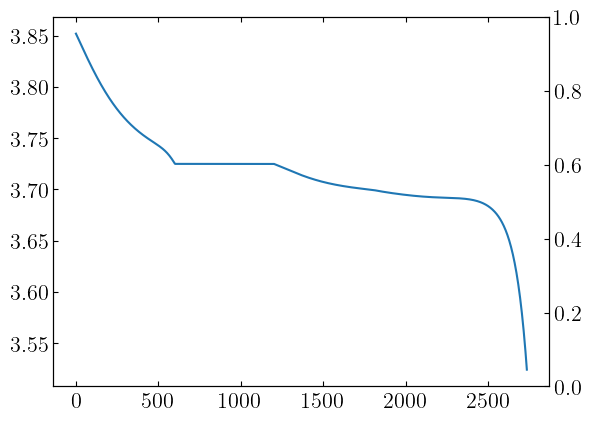

In [71]:
tt,vv,ii = sim_PyBaMM.get_volt_variable(1)

f, ax = plt.subplots()
axt = ax.twinx()
ax.plot(tt,vv)


print(tt[-1])

In [2]:
def gen_data(I, save = True):
    t,u = sim_PyBaMM.get_voltage(I)
    i = np.ones_like(t) * I
    data = np.array([i,u]).T

    return data,t[-1]

In [3]:
i = np.arange(1, 41)
D = np.zeros((len(i),1000,2))
ts = []
for Is,n in zip(i,trange(len(i))):
    I = np.round(Is / 20,2)

    ts.append(gen_data(I)[1])


 98%|█████████▊| 39/40 [00:17<00:00,  2.25it/s]


In [4]:
def f_It(I,k,n):
    return k * I**(-n)

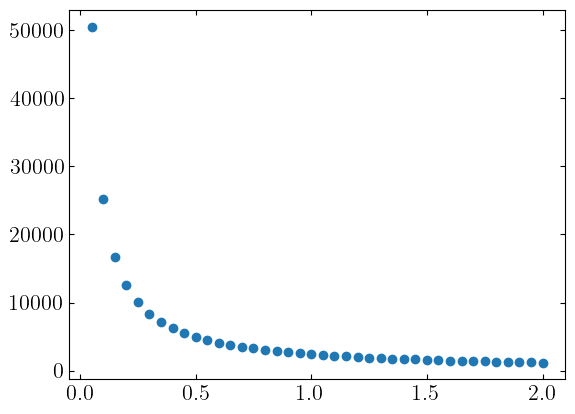

In [5]:
plt.scatter(i/20,ts)


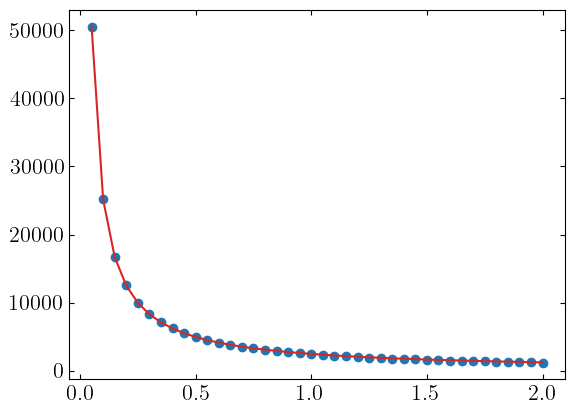

In [6]:
def f_It(I,k,n):
    return k * I**(-n)
i = np.arange(1, 41)
popt, pcov = scipy.optimize.curve_fit(f_It, i/20, ts)
plt.scatter(i/20,ts)
plt.plot(i/20,f_It(i/20,*popt),color='tab:red')

In [16]:
i = np.arange(1, 41)
D = np.zeros((len(i),1000,2))
for Is,n in zip(i,trange(len(i))):
    I = np.round(Is / 20,2)

    D[n,...] = gen_data(I)[0]

 98%|█████████▊| 39/40 [00:17<00:00,  2.17it/s]


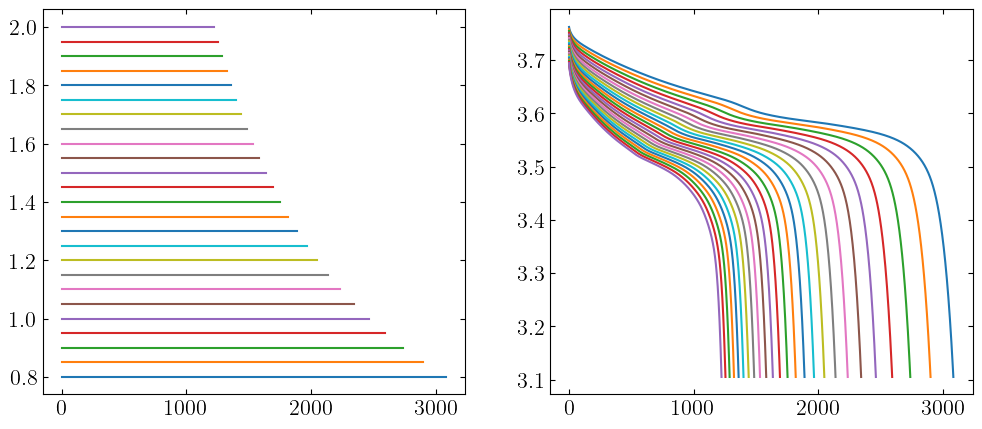

In [17]:
i = np.arange(1, 41)
f,ax = plt.subplots(1,2,figsize=(12,5))
for N in range(15,len(i)):
    ax[0].plot(np.linspace(0,f_It(i[N]/20,*popt),len(D[N,:,0])),D[N,:,0])
    ax[1].plot(np.linspace(0,f_It(i[N]/20,*popt),len(D[N,:,0])),D[N,:,1])

In [18]:
X_train, X_, y_train, y_ = train_test_split(D[:,:,:1], D[:,:,1:], test_size=0.3, random_state=42)

X_train = X_train[:,0,:]
X_ = X_[:,0,:]

print(X_train.shape, y_train.shape)
X_valid, X_test, y_valid, y_test = train_test_split(X_, y_, test_size=0.3, random_state=42)





print(X_train.shape, y_train.shape, X_valid.shape, y_valid.shape, X_test.shape, y_test.shape)

(28, 1) (28, 1000, 1)
(28, 1) (28, 1000, 1) (8, 1) (8, 1000, 1) (4, 1) (4, 1000, 1)


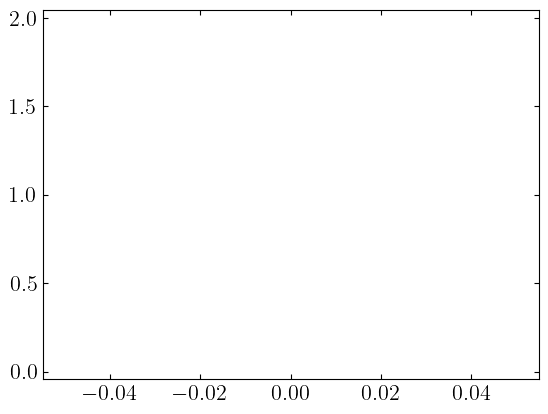

In [19]:
for i in range(len(X_train)):
    plt.plot(X_train[i])
plt.show()

In [ ]:
model = keras.Sequential([
    keras.layers.Input((1,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1000)   # outputs the whole sequence
])


model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

In [23]:
epochs = 500     ## Number of epoch to run
batch_size = 80  ## Number of samples per gradient update

es = keras.callbacks.EarlyStopping('val_loss', patience=50, restore_best_weights = True)

# Train the model
history = model.fit(
  X_train, y_train,
  epochs=epochs,
  verbose = 1,
  validation_data=(X_valid, y_valid),
  callbacks=[es]
)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step - loss: 12.9108 - mae: 3.5915 - val_loss: 12.8512 - val_mae: 3.5833
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 12.8309 - mae: 3.5802 - val_loss: 12.7619 - val_mae: 3.5707
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 12.7370 - mae: 3.5669 - val_loss: 12.6449 - val_mae: 3.5541
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 12.6143 - mae: 3.5495 - val_loss: 12.4911 - val_mae: 3.5321
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.4530 - mae: 3.5263 - val_loss: 12.2922 - val_mae: 3.5035
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.2447 - mae: 3.4962 - val_loss: 12.0393 - val_mae: 3.4667
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 11.9804 - mae: 3.4574 - val_loss: 11.7235 - val_mae: 3.4200
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 11.6509 - mae: 3.4083 - val_loss: 11.3365 - val_mae: 3.3617
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - los

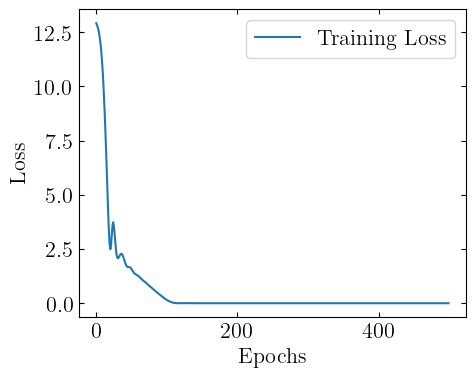

In [24]:
train_loss = history.history['loss']
#valid_loss = history.history['val_loss']

fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4))
ax1.plot(train_loss, label='Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()


In [25]:
#pred = model.predict(X_test[0])
print(X_test[0])


[1.3]


In [28]:
for i in trange(5):
    #t_t, u_t = sim_PyBaMM.get_voltage(0.7)
    pred = model.predict([I_test],verbose=0)


100%|██████████| 5/5 [00:00<00:00, 26.78it/s]


[1.18]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


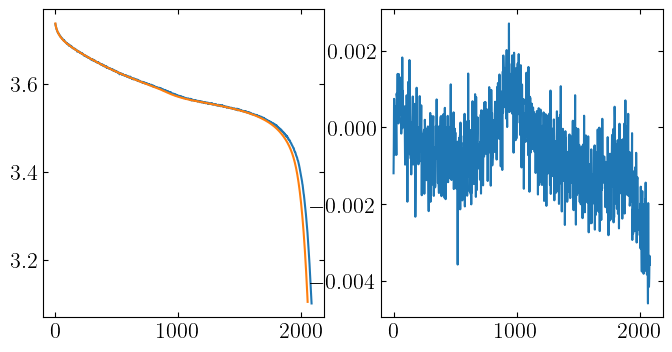

In [33]:
I_test = 1.18
I_test = np.array([I_test])
print(I_test)

pred = model.predict([I_test])
t_t, u_t = sim_PyBaMM.get_voltage(I_test[0])



f,ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(np.linspace(0,f_It(I_test,*popt),1000),pred.ravel())
ax[0].plot(t_t,u_t)

ax[1].plot(np.linspace(0,f_It(I_test,*popt),1000),pred.ravel() - u_t)
